In [1]:
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import scipy as sp
from scipy import optimize
from scipy import fftpack
import skopt as opt
from skimage.color import rgb2gray
from skimage.restoration import denoise_tv_chambolle
from scipy.fftpack import dct, idct
import os
from rasterio.windows import from_bounds, Window
import imageio.v2 as imageio
import math

1. Choosing the urban/forest areas (code from previous labs)

Found bands: {'B04': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B04.jp2', 'B03': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B03.jp2', 'B02': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B02.jp2'}


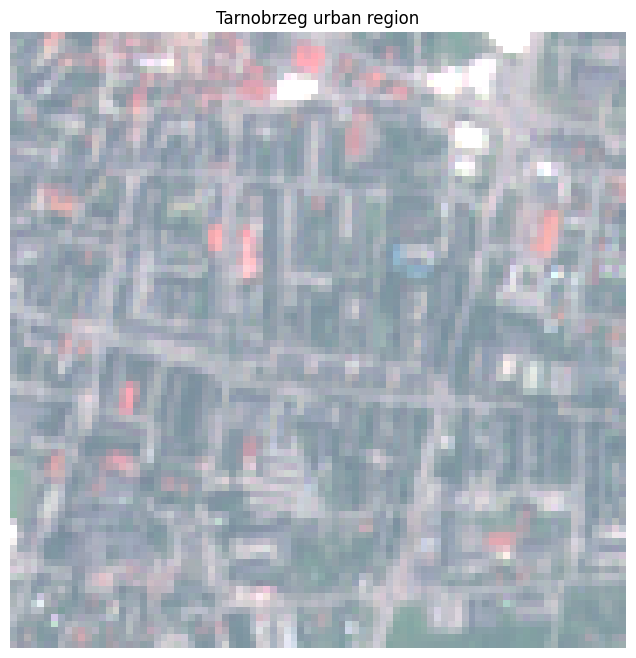

In [8]:
folder = r"C:\ml_amit\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\GRANULE\L1C_T34UEB_A052972_20250813T094043\IMG_DATA"
band_paths = {b: glob.glob(f"{folder}/T34UEB_20250813T094041_{b}.jp2")[0] for b in ["B04", "B03", "B02"]}
print("Found bands:", band_paths)

lon, lat = 21.675, 50.570   # top lake coordinates

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32634", always_xy=True)
x, y = transformer.transform(lon, lat)
dx = 450
dy = 450
xmin, ymin, xmax, ymax = x - dx, y - dy, x + dx, y + dy

## healper functions to load only the cropped area of interest instead of whole image
def read_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
    return data
##crop each band
b4_crop = read_crop(band_paths["B04"], (xmin, ymin, xmax, ymax))  # Red
b3_crop = read_crop(band_paths["B03"], (xmin, ymin, xmax, ymax))  # Green
b2_crop = read_crop(band_paths["B02"], (xmin, ymin, xmax, ymax))  # Blue

#stack normalize and exclude outliers
rgb_crop = np.dstack((b4_crop, b3_crop, b2_crop)).astype(np.float32)
rgb_crop /= np.percentile(rgb_crop, 99)
rgb_crop_urban = np.clip(rgb_crop, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_crop_urban)
plt.title("Tarnobrzeg urban region")
plt.axis("off")
plt.show()

Found bands: {'B04': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B04.jp2', 'B03': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B03.jp2', 'B02': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B02.jp2'}


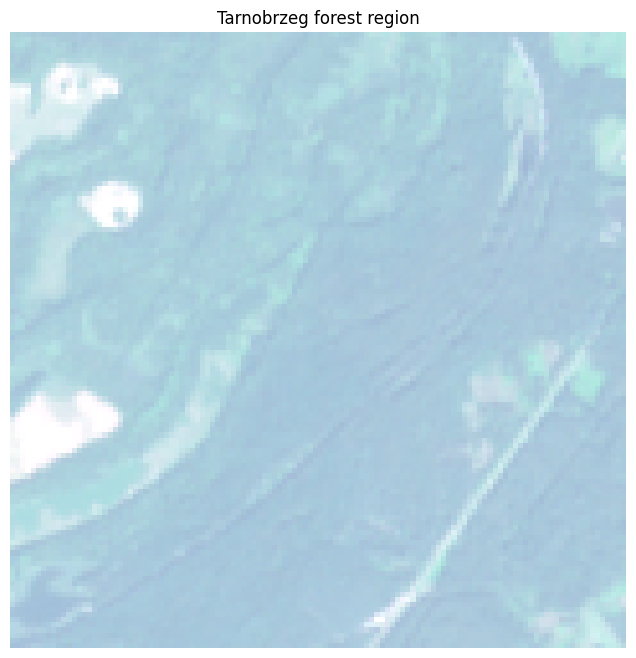

In [7]:
#code from lab1
folder = r"C:\ml_amit\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\GRANULE\L1C_T34UEB_A052972_20250813T094043\IMG_DATA"
band_paths = {b: glob.glob(f"{folder}/T34UEB_20250813T094041_{b}.jp2")[0] for b in ["B04", "B03", "B02"]}
print("Found bands:", band_paths)

lon, lat = 21.631, 50.50   # top lake coordinates

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32634", always_xy=True)
x, y = transformer.transform(lon, lat)
dx = 600
dy = 600
xmin, ymin, xmax, ymax = x - dx, y - dy, x + dx, y + dy

## healper functions to load only the cropped area of interest instead of whole image
def read_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
    return data
##crop each band
b4_crop = read_crop(band_paths["B04"], (xmin, ymin, xmax, ymax))  # Red
b3_crop = read_crop(band_paths["B03"], (xmin, ymin, xmax, ymax))  # Green
b2_crop = read_crop(band_paths["B02"], (xmin, ymin, xmax, ymax))  # Blue

#stack normalize and exclude outliers
rgb_crop = np.dstack((b4_crop, b3_crop, b2_crop)).astype(np.float32)
rgb_crop /= np.percentile(rgb_crop, 99)
rgb_crop_forest = np.clip(rgb_crop, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_crop_forest)
plt.title("Tarnobrzeg forest region")
plt.axis("off")
plt.show()

Found bands: {'B04': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B04.jp2', 'B03': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B03.jp2', 'B02': 'C:\\ml_amit\\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\\GRANULE\\L1C_T34UEB_A052972_20250813T094043\\IMG_DATA/T34UEB_20250813T094041_B02.jp2'}


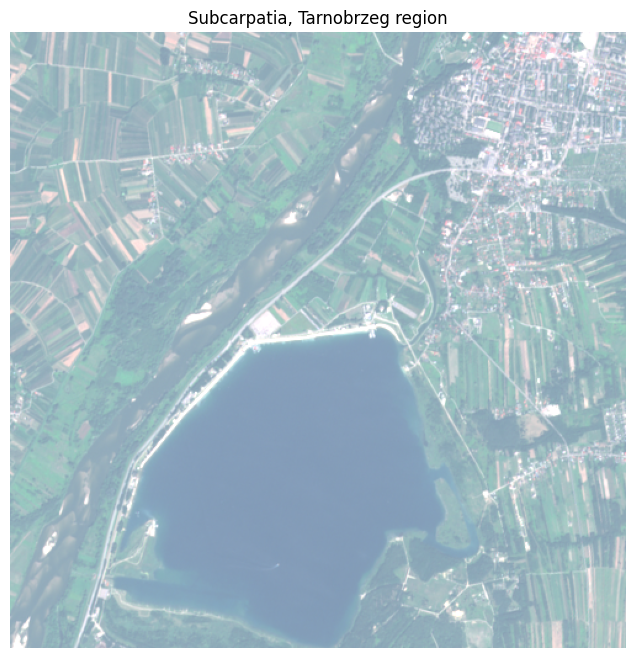

In [9]:
#code from lab1
folder = r"C:\ml_amit\S2A_MSIL1C_20250813T094041_N0511_R036_T34UEB_20250813T100305.SAFE\GRANULE\L1C_T34UEB_A052972_20250813T094043\IMG_DATA"
band_paths = {b: glob.glob(f"{folder}/T34UEB_20250813T094041_{b}.jp2")[0] for b in ["B04", "B03", "B02"]}
print("Found bands:", band_paths)

lon, lat = 21.6476, 50.5527   # top lake coordinates

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32634", always_xy=True)
x, y = transformer.transform(lon, lat)
dx = 2500
dy = 2500
xmin, ymin, xmax, ymax = x - dx, y - dy, x + dx, y + dy

## healper functions to load only the cropped area of interest instead of whole image
def read_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
    return data
##crop each band
b4_crop = read_crop(band_paths["B04"], (xmin, ymin, xmax, ymax))  # Red
b3_crop = read_crop(band_paths["B03"], (xmin, ymin, xmax, ymax))  # Green
b2_crop = read_crop(band_paths["B02"], (xmin, ymin, xmax, ymax))  # Blue

#stack normalize and exclude outliers
rgb_crop = np.dstack((b4_crop, b3_crop, b2_crop)).astype(np.float32)
rgb_crop /= np.percentile(rgb_crop, 99)
new_rgb = np.clip(rgb_crop, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(new_rgb)
plt.title("Subcarpatia, Tarnobrzeg region")
plt.axis("off")
plt.show()

2. Bayes classifier

a) Histograms (code from prev lab)

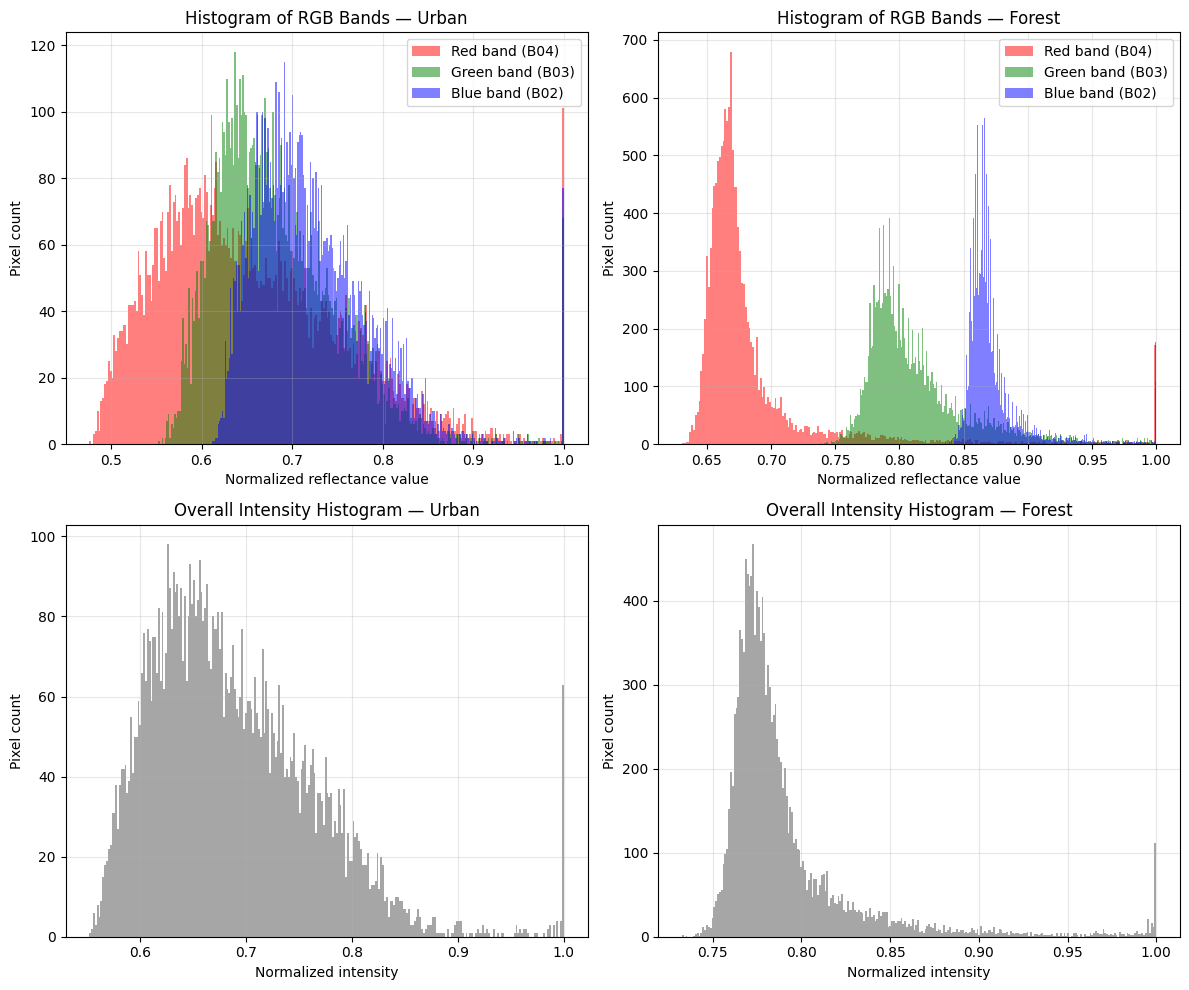

In [19]:
def bands_and_intensity(rgb):
    r = rgb[:, :, 0].ravel()
    g = rgb[:, :, 1].ravel()
    b = rgb[:, :, 2].ravel()
    mask = np.isfinite(r) & np.isfinite(g) & np.isfinite(b)
    r = r[mask]
    g = g[mask]
    b = b[mask]

    intensity = np.mean(rgb, axis=2).ravel()
    intensity = intensity[mask]

    return r, g, b, intensity

r_u, g_u, b_u, i_u = bands_and_intensity(rgb_crop_urban)
r_f, g_f, b_f, i_f = bands_and_intensity(rgb_crop_forest)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes[0, 0]
ax.hist(r_u, bins=256, color='red',   alpha=0.5, label='Red band (B04)')
ax.hist(g_u, bins=256, color='green', alpha=0.5, label='Green band (B03)')
ax.hist(b_u, bins=256, color='blue',  alpha=0.5, label='Blue band (B02)')
ax.set_title("Histogram of RGB Bands — Urban")
ax.set_xlabel("Normalized reflectance value")
ax.set_ylabel("Pixel count")
ax.grid(alpha=0.3)
ax.legend()
ax = axes[0, 1]
ax.hist(r_f, bins=256, color='red',   alpha=0.5, label='Red band (B04)')
ax.hist(g_f, bins=256, color='green', alpha=0.5, label='Green band (B03)')
ax.hist(b_f, bins=256, color='blue',  alpha=0.5, label='Blue band (B02)')
ax.set_title("Histogram of RGB Bands — Forest")
ax.set_xlabel("Normalized reflectance value")
ax.set_ylabel("Pixel count")
ax.grid(alpha=0.3)
ax.legend()
ax = axes[1, 0]
ax.hist(i_u, bins=256, color='gray', alpha=0.7)
ax.set_title("Overall Intensity Histogram — Urban")
ax.set_xlabel("Normalized intensity")
ax.set_ylabel("Pixel count")
ax.grid(alpha=0.3)
ax = axes[1, 1]
ax.hist(i_f, bins=256, color='gray', alpha=0.7)
ax.set_title("Overall Intensity Histogram — Forest")
ax.set_xlabel("Normalized intensity")
ax.set_ylabel("Pixel count")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**b) Bayes** 

What the code does?
* For each class (urban/forest) and band (R,G,B), fitted a one-inflated Beta: `pi` (mass at 1.0) + Beta(`alpha`,`beta`) on (0,1) via method of moments
* Computed log-likelihoods per band with that model; sum over R,G,B (naïve independence) and added equal log-priors
* For each pixel in `new_rgb`, picked the class with the larger log-posterior → `forest_mask`
* overlay from the mask and plot it with the original image to show classofocation


One-inflated Beta parameters (pi, alpha, beta):

Urban:
  R: pi=0.012, alpha=15.34, beta=8.22
  G: pi=0.008, alpha=34.35, beta=16.10
  B: pi=0.009, alpha=40.72, beta=15.85

Forest:
  R: pi=0.012, alpha=65.62, beta=30.54
  G: pi=0.007, alpha=71.61, beta=16.36
  B: pi=0.012, alpha=214.41, beta=31.56


Text(0.5, 1.0, 'Bayes classification overlay (Blue=Forest, Red=Urban)')

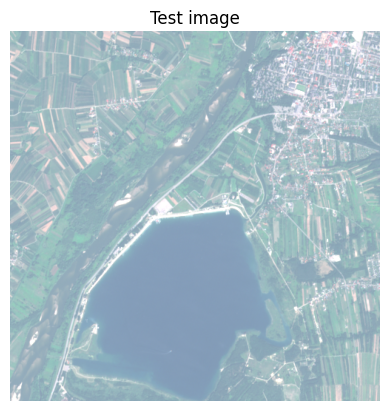

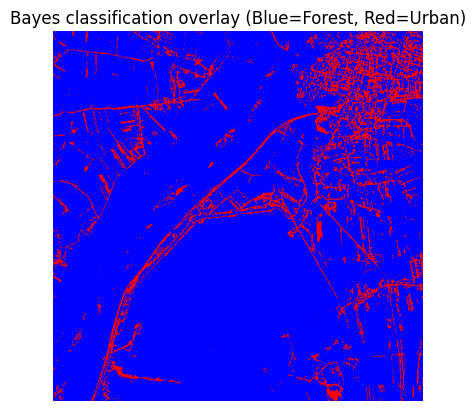

In [ ]:
def fit_one_inflated_beta_moments(x, eps=1e-6):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.clip(x, 0.0, 1.0)
    pi = float(np.mean(x >= 1.0 - eps)) # Probability mass at 1.0 
    x_cont = x[(x > eps) & (x < 1.0 - eps)] # Continuous component strictly inside (0,1)
    if x_cont.size < 3:
        return pi, 1.0, 1.0
    m = float(np.mean(x_cont))
    v = float(np.var(x_cont))  # population variance
    if v <= 0:
        return pi, 1.0, 1.0
    t = (m*(1.0 - m) / v) - 1.0
    if not np.isfinite(t) or t <= 0:
        return pi, 1.0, 1.0
    a = m * t
    b = (1.0 - m) * t
    if a <= 0 or b <= 0 or not np.isfinite(a) or not np.isfinite(b):
        return pi, 1.0, 1.0
    return float(pi), float(a), float(b)

def logpdf_beta(x, a, b):
    lgB = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    return (a - 1.0) * np.log(x) + (b - 1.0) * np.log(1.0 - x) - lgB

def logpdf_one_inflated_beta(x, pi, a, b, eps=1e-6):
    x = np.asarray(x)
    x = np.clip(x, 0.0, 1.0)
    cont = (x < 1.0 - eps)  # treat near-1 as point mass
    logs = np.empty_like(x, dtype=float)
    x_safe = np.clip(x[cont], 1e-12, 1.0 - 1e-12)
    logs[cont] = np.log(max(1.0 - pi, 1e-12)) + logpdf_beta(x_safe, a, b)
    logs[~cont] = np.log(max(pi, 1e-12))
    return logs

# parameters
params_urban = { 'R': fit_one_inflated_beta_moments(r_u),
                 'G': fit_one_inflated_beta_moments(g_u),
                 'B': fit_one_inflated_beta_moments(b_u) }
params_forest = { 'R': fit_one_inflated_beta_moments(r_f),
                  'G': fit_one_inflated_beta_moments(g_f),
                  'B': fit_one_inflated_beta_moments(b_f) }

# Bayes function
def classify_rgb_image(img, params_f, params_u, prior_f=0.5, prior_u=0.5, eps=1e-6):
    """Return boolean mask: True=Forest, False=Urban"""
    img = np.clip(img, 0.0, 1.0)
    r = img[..., 0]
    g = img[..., 1]
    b = img[..., 2]

    ll_f = (logpdf_one_inflated_beta(r, *params_f['R'], eps=eps) +
            logpdf_one_inflated_beta(g, *params_f['G'], eps=eps) +
            logpdf_one_inflated_beta(b, *params_f['B'], eps=eps) +
            np.log(prior_f + 1e-12))
    ll_u = (logpdf_one_inflated_beta(r, *params_u['R'], eps=eps) +
            logpdf_one_inflated_beta(g, *params_u['G'], eps=eps) +
            logpdf_one_inflated_beta(b, *params_u['B'], eps=eps) +
            np.log(prior_u + 1e-12))

    return ll_f > ll_u

test_img = np.array(new_rgb, dtype=float)
forest_mask = classify_rgb_image(test_img, params_forest, params_urban) #classify

# red/blue overlay
overlay = np.zeros_like(test_img)
overlay[..., 0] = (forest_mask).astype(np.uint8) * 255  # Red for urban
overlay[..., 2] = (~forest_mask).astype(np.uint8) * 255   # Blue for forest

print("One-inflated Beta parameters (pi, alpha, beta):\n")
print("Urban:")
for k, v in params_urban.items():
    print(f"  {k}: pi={v[0]:.3f}, alpha={v[1]:.2f}, beta={v[2]:.2f}")
print("\nForest:")
for k, v in params_forest.items():
    print(f"  {k}: pi={v[0]:.3f}, alpha={v[1]:.2f}, beta={v[2]:.2f}")

plt.figure()
plt.imshow(test_img)
plt.axis('off')
plt.title("Test image")

plt.figure()
plt.imshow(overlay.astype(np.uint8))
plt.axis('off')
plt.title("Bayes classification overlay (Blue=Forest, Red=Urban)")

The fitted PDFs: forest has higher, tighter reflectance in G/B (large α+β; means ≈0.81/0.87), while urban is darker and more variable (smaller α+β), with only a tiny spike at 1.0, so saturation isn’t driving results. The overlay matches this- vegetated fields classify as blue (forest) and the built-up region as red (urban). Thin red lines along roads/shorelines and some speckle at boundaries are expected from per-pixel naïve Bayes and mixed/shadowed pixels. Water appears blue because we only have two classes; it’s closer to forest than urban in RGB. 


**3. kNN classifier**

Whats in the code
* Training sampling flattens each RGB crop to ((N,3)), randomly picks up to `n_samples` pixels, and assigns a class label 
* Training set samples `N_PER_CLASS=1500` from each crop, then stacks features into `X_train` and `y_train`
* Test features: flattens the target image `new_rgb` to `X_test` (one RGB vector per pixel)
* k-NN (`knn_predict`) for test pixels processed in chunks, computes Euclidean distances to all training pixels, finds the k nearest neighbors using `np.argpartition`, and does majority vote over their labels 
* Run for k=1,3,5: predicts labels for each k

and then the visualisation part 

In [21]:
def to_training(rgb, label, n_samples):
    h, w, _ = rgb.shape
    flat = rgb.reshape(-1, 3)
    idx = np.random.default_rng(123).choice(flat.shape[0], size=min(n_samples, flat.shape[0]), replace=False)
    X = flat[idx]
    y = np.full(X.shape[0], label, dtype=np.uint8)
    return X, y

# Subsample counts
N_PER_CLASS = 1500
X_u, y_u = to_training(rgb_crop_urban, 0, N_PER_CLASS)  
X_f, y_f = to_training(rgb_crop_forest, 1, N_PER_CLASS) 
X_train = np.vstack([X_u, X_f]).astype(np.float32)
y_train = np.concatenate([y_u, y_f])

test_img = np.array(new_rgb, dtype=float)
X_test = test_img.reshape(-1, 3).astype(np.float32) # Flatten

# k-NN from scratch
def knn_predict(X_train, y_train, X_test, k=3, chunk=2048):
    n_test = X_test.shape[0]
    y_pred = np.empty(n_test, dtype=np.uint8)
    for start in range(0, n_test, chunk):
        end = min(start + chunk, n_test)
        T = X_test[start:end]  # (t, d)
        diffs = T[:, None, :] - X_train[None, :, :]
        d2 = np.sum(diffs * diffs, axis=2) 
        nn_idx = np.argpartition(d2, kth=k-1, axis=1)[:, :k] #k nearest neighbors
        nn_labels = y_train[nn_idx]  # (t, k)
        votes_forest = np.sum(nn_labels == 1, axis=1) 
        votes_urban = k - votes_forest
        y_pred[start:end] = (votes_forest > votes_urban).astype(np.uint8)
    return y_pred


# Run for k = 1, 3, 5
results = {}
for k in (1, 3, 5):
    pred = knn_predict(X_train, y_train, X_test, k=k, chunk=1024)
    mask = pred.reshape(test_img.shape[0], test_img.shape[1]).astype(bool)  # True=forest
    results[k] = mask

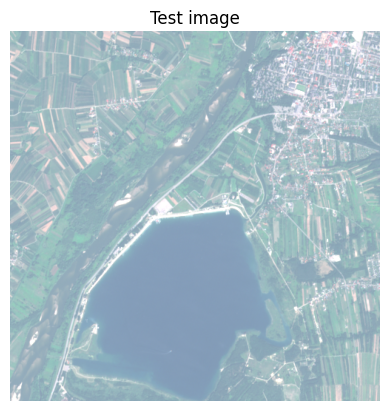

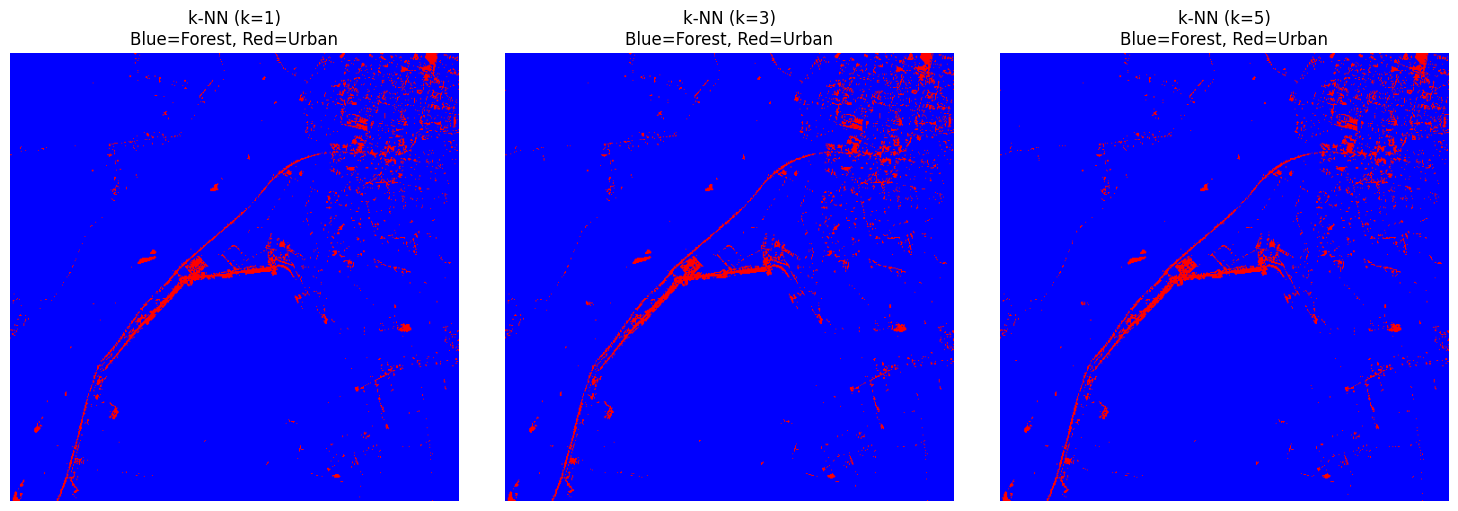

In [22]:
def make_overlay(mask):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)
    overlay[..., 2] = (~mask * 255).astype(np.uint8)     # Blue for forest
    overlay[..., 0] = ((mask) * 255).astype(np.uint8)  # Red for urban
    return overlay

plt.figure()
plt.imshow(test_img)
plt.axis('off')
plt.title("Test image")


ks = [1, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, ks):
    ov = make_overlay(results[k])
    ax.imshow(ov)
    ax.axis('off')
    ax.set_title(f"k-NN (k={k})\nBlue=Forest, Red=Urban")
plt.tight_layout()
plt.show()


All three maps agree on the big picture: most of the scene is forest with urban clustered in the built-up area and along linear features (roads etc). As k increases, the result gets smoother: k=1 shows the most salt-and-pepper speckle and isolated red dots; k=3 removes many of those outliers while preserving the urban clusters; k=5 is the smoothest, further reducing stray red pixels but starting to thin/erode some very small or narrow urban structures. In short: k=1 is sensitive/noisy, k=3 balances noise and detail, k=5 is robust but slightly more conservative on fine features.
